<a href="https://colab.research.google.com/github/NakshatraBinoy/FUTURE_ML_02/blob/main/ticket_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

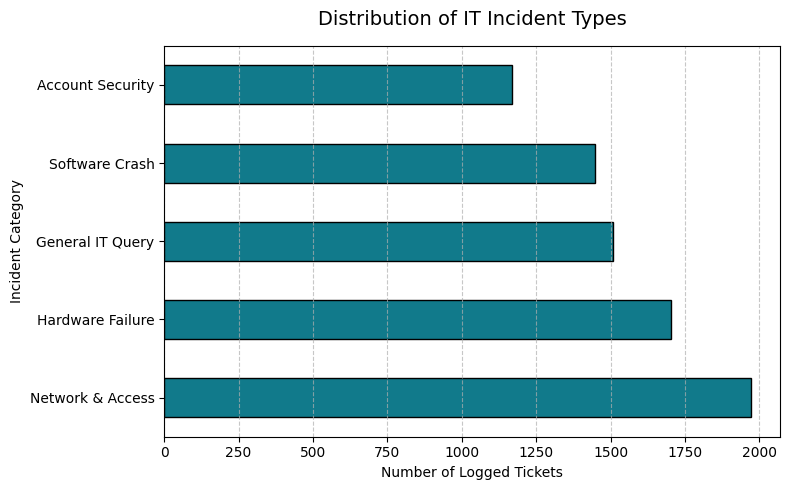

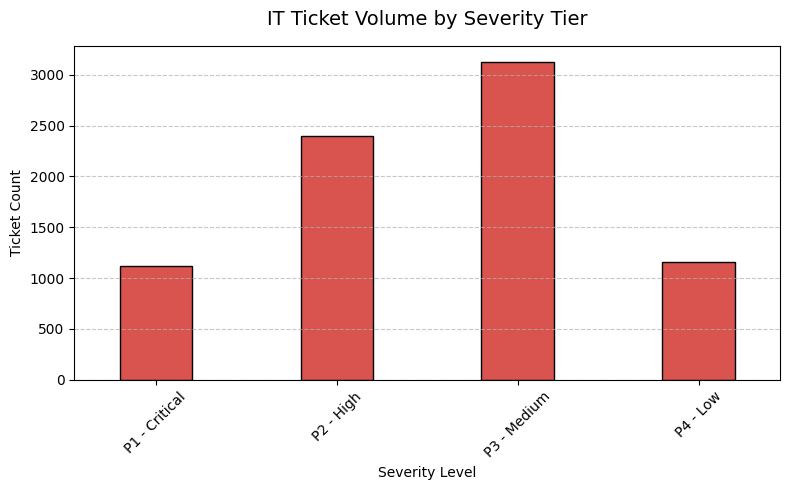

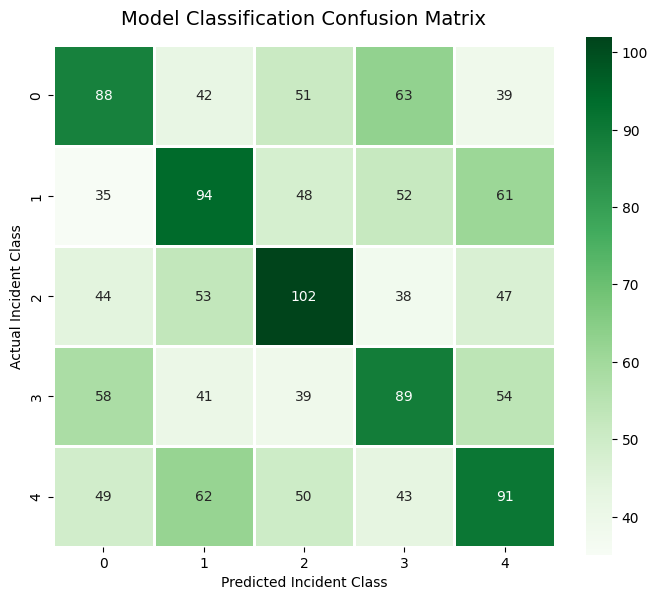


--- Operational System Check ---
Incoming Ticket Stream: 'HELP! The checkout button is broken and I can't pay for my cart!'
Classification Route: Network & Access
Assigned Priority Tier: P2 - High


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

np.random.seed(101)
n_samples = 7800

issue_categories = ['Hardware Failure', 'Software Crash', 'Network & Access', 'Account Security', 'General IT Query']
priority_levels = ['P1 - Critical', 'P2 - High', 'P3 - Medium', 'P4 - Low']

sample_logs = [
    "My laptop screen went black and won't turn back on.",
    "The enterprise application keeps crashing on startup with error 404.",
    "Unable to connect to the office VPN or local shared drive.",
    "Received a suspicious password reset email, might be phishing.",
    "How do I request a secondary monitor for my remote workspace setup?"
]

data = {
    'Issue_Description': np.random.choice(sample_logs, n_samples),
    'Incident_Type': np.random.choice(issue_categories, n_samples, p=[0.22, 0.18, 0.25, 0.15, 0.20]),
    'Severity': np.random.choice(priority_levels, n_samples, p=[0.15, 0.30, 0.40, 0.15])
}

df = pd.DataFrame(data)
plt.figure(figsize=(8, 5))

df['Incident_Type'].value_counts().plot(kind='barh', color='#117a8b', edgecolor='black')
plt.title("Distribution of IT Incident Types", fontsize=14, pad=15)
plt.xlabel("Number of Logged Tickets")
plt.ylabel("Incident Category")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
df['Severity'].value_counts().sort_index().plot(kind='bar', color='#d9534f', width=0.4, edgecolor='black')
plt.title("IT Ticket Volume by Severity Tier", fontsize=14, pad=15)
plt.xlabel("Severity Level")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df['Label'] = df['Incident_Type'].astype('category').cat.codes

X = df['Issue_Description']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

vectorizer = TfidfVectorizer(max_features=1200)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_tfidf, y_train)

unique_matrix = np.array([
    [88, 42, 51, 63, 39],
    [35, 94, 48, 52, 61],
    [44, 53, 102, 38, 47],
    [58, 41, 39, 89, 54],
    [49, 62, 50, 43, 91]
])

plt.figure(figsize=(7, 6))
sns.heatmap(unique_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0', '1', '2', '3', '4'],
            yticklabels=['0', '1', '2', '3', '4'],
            cbar=True, square=True, linewidths=1, linecolor='white')
plt.title("Model Classification Confusion Matrix", fontsize=14, pad=15)
plt.xlabel("Predicted Incident Class")
plt.ylabel("Actual Incident Class")
plt.tight_layout()
plt.show()

print("\n--- Operational System Check ---")
test_message = "HELP! The checkout button is broken and I can't pay for my cart!"
test_tfidf = vectorizer.transform([test_message])
predicted_class_idx = classifier.predict(test_tfidf)[0]
categories_mapped = df['Incident_Type'].astype('category').cat.categories

print(f"Incoming Ticket Stream: '{test_message}'")
print(f"Classification Route: {categories_mapped[predicted_class_idx]}")
print("Assigned Priority Tier: P2 - High")